# 02 preprocessing dual ctxt ROI V6 3cat crop quality

Objectif :

Améliorer la qualité des crops et des ROI sur nos trois catégories diagnostic avant de relancer Dinomaly.

On ne réentraîne aucun modèle ici.

On reprend les sorties de :

```text
02_preprocessing_dual_ctxt_roi_v5_3cat.ipynb
```

et on prépare des variantes de preprocessing plus propres pour un futur notebook Dinomaly V14.

Catégories traitées :

```text
hss iad | Casting_class1
hss iad | STEEL
mvtec   | cable
```

Priorité :

```text
améliorer AUPIMO
réduire les zones non pertinentes
filtrer les crops normaux trop bruités
garder les anomalies bien centrées sur le défaut
comparer plusieurs variantes de ROI et de sélection de crops
préparer une stratégie par catégorie
```


## 1. Imports

In [2]:
##############
#  Imports   #
##############

import os
import math
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw, ImageFilter, ImageOps

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from scipy import ndimage
    SCIPY_AVAILABLE = True
except Exception as error:
    SCIPY_AVAILABLE = False
    print("scipy indisponible:", error)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 2. Configuration

In [3]:
##########################
#  Global configuration  #
##########################

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "results"

SOURCE_TAG = "preprocessing_dual_context_roi_v5_3cat"
SOURCE_RESULTS_DIR = RESULTS_DIR / SOURCE_TAG
SOURCE_DATA_DIR = PROCESSED_DIR / SOURCE_TAG

SOURCE_IMAGE_METADATA_CSV = SOURCE_RESULTS_DIR / "dual_context_roi_v5_3cat_image_metadata.csv"
SOURCE_CROP_METADATA_CSV = SOURCE_RESULTS_DIR / "dual_context_roi_v5_3cat_crop_metadata.csv"
SOURCE_SUMMARY_CSV = SOURCE_RESULTS_DIR / "dual_context_roi_v5_3cat_summary.csv"

RUN_TAG = "preprocessing_dual_context_roi_v6_3cat_crop_quality"
RUN_RESULTS_DIR = RESULTS_DIR / RUN_TAG
RUN_DATA_DIR = PROCESSED_DIR / RUN_TAG

RUN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RUN_DATA_DIR.mkdir(parents=True, exist_ok=True)

TARGET_PAIRS = [
    ("hss-iad", "Casting_class1"),
    ("hss-iad", "STEEL"),
    ("mvtec", "cable"),
]

MASK_THRESHOLD = 127
LOCAL_SIZE = 384

# Limites pour produire plusieurs variantes sans exploser le futur entraînement.
MAX_TRAIN_NORMAL_PER_VARIANT = 1200
MAX_TEST_NORMAL_PER_VARIANT = 250
MAX_TEST_ANOMALY_PER_VARIANT = 400

# Seuils de qualité crop.
MIN_ROI_COVERAGE_NORMAL = 0.35
MIN_ROI_COVERAGE_ANOMALY = 0.20
MAX_ROI_COVERAGE = 0.98
MIN_DEFECT_PIXELS_ANOMALY = 8
MIN_DEFECT_RATIO_IN_ROI = 0.0002

# Nombre maximum de crops retenus par image pour les variantes compactes.
MAX_NORMAL_CROPS_PER_IMAGE = 4
MAX_ANOMALY_CROPS_PER_IMAGE = 5

# Variantes de sélection préparées pour Dinomaly V14.
VARIANT_CONFIGS = [
    {
        "variant_id": "v6_base_filtered",
        "description": "V5 crops avec filtrage qualité léger",
        "roi_variant": "roi",
        "selection_mode": "base_filtered",
    },
    {
        "variant_id": "v6_roi_erode1_filtered",
        "description": "ROI érodée 1 pixel plus filtrage qualité",
        "roi_variant": "roi_erode_1",
        "selection_mode": "base_filtered",
    },
    {
        "variant_id": "v6_roi_erode2_filtered",
        "description": "ROI érodée 2 pixels plus filtrage qualité",
        "roi_variant": "roi_erode_2",
        "selection_mode": "base_filtered",
    },
    {
        "variant_id": "v6_top_quality_balanced",
        "description": "Crops les plus propres, équilibrés par image",
        "roi_variant": "roi_erode_1",
        "selection_mode": "top_quality_balanced",
    },
    {
        "variant_id": "v6_defect_centered",
        "description": "Crops anormaux centrés défaut et normaux très ROI",
        "roi_variant": "roi_erode_1",
        "selection_mode": "defect_centered",
    },
]

print("Project root:", PROJECT_ROOT)
print("Source crop metadata:", SOURCE_CROP_METADATA_CSV)
print("Run data dir:", RUN_DATA_DIR)
print("Run results dir:", RUN_RESULTS_DIR)
print("Target pairs:", TARGET_PAIRS)
print("Variants:", [item["variant_id"] for item in VARIANT_CONFIGS])


Project root: /home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus
Source crop metadata: /home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v5_3cat/dual_context_roi_v5_3cat_crop_metadata.csv
Run data dir: /home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/data/processed/preprocessing_dual_context_roi_v6_3cat_crop_quality
Run results dir: /home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality
Target pairs: [('hss-iad', 'Casting_class1'), ('hss-iad', 'STEEL'), ('mvtec', 'cable')]
Variants: ['v6_base_filtered', 'v6_roi_erode1_filtered', 'v6_roi_erode2_filtered', 'v6_top_quality_balanced', 'v6_defect_centered']


## 3. Chargement des métadonnées V5

In [4]:
#########################
#  Load V5 metadata     #
#########################

required_files = [
    SOURCE_IMAGE_METADATA_CSV,
    SOURCE_CROP_METADATA_CSV,
    SOURCE_SUMMARY_CSV,
]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing source file: {path}")

image_metadata_v5_df = pd.read_csv(SOURCE_IMAGE_METADATA_CSV)
crop_metadata_v5_df = pd.read_csv(SOURCE_CROP_METADATA_CSV)
summary_v5_df = pd.read_csv(SOURCE_SUMMARY_CSV)

target_set = set(TARGET_PAIRS)

image_keep = []

for _, row in image_metadata_v5_df.iterrows():
    pair = (row["dataset"], row["category"])
    image_keep.append(pair in target_set)

crop_keep = []

for _, row in crop_metadata_v5_df.iterrows():
    pair = (row["dataset"], row["category"])
    crop_keep.append(pair in target_set)

summary_keep = []

for _, row in summary_v5_df.iterrows():
    pair = (row["dataset"], row["category"])
    summary_keep.append(pair in target_set)

image_df = image_metadata_v5_df[image_keep].copy().reset_index(drop=True)
crop_df = crop_metadata_v5_df[crop_keep].copy().reset_index(drop=True)
summary_selected_df = summary_v5_df[summary_keep].copy().reset_index(drop=True)

print("Images selected:", image_df.shape)
print("Crops selected:", crop_df.shape)

print()
print("V5 summary selected:")
display(summary_selected_df)

print()
print("Crop counts:")
display(
    crop_df
    .groupby(["dataset", "category", "split", "image_true_label", "crop_true_label"])
    .size()
    .reset_index(name="count")
)

display(crop_df.head())


Images selected: (1705, 22)
Crops selected: (10006, 24)

V5 summary selected:


,dataset,category,images,anomaly_images,crops,crop_anomalies,mean_crops_per_image,mean_roi_area_ratio_context,mean_defect_roi_coverage_context,min_defect_roi_coverage_context,mean_crop_roi_coverage
0,hss-iad,Casting_class1,471,19,2633,114,5.590234,0.505443,0.986687,0.930268,0.610115
1,hss-iad,STEEL,860,180,5129,1007,5.963953,0.695422,0.991599,0.963918,0.801953
2,mvtec,cable,374,92,2244,538,6.000000,0.812234,1.000000,1.000000,0.922202



Crop counts:


,dataset,category,split,image_true_label,crop_true_label,count
0,hss-iad,Casting_class1,test,0,0,72
1,hss-iad,Casting_class1,test,1,1,114
2,hss-iad,Casting_class1,train,0,0,2447
3,hss-iad,STEEL,test,0,0,1067
4,hss-iad,STEEL,test,1,0,72
5,hss-iad,STEEL,test,1,1,1007
6,hss-iad,STEEL,train,0,0,2983
7,mvtec,cable,test,0,0,348
8,mvtec,cable,test,1,0,14
9,mvtec,cable,test,1,1,538


,image_id,crop_id,dataset,category,split,defect_type,image_true_label,crop_true_label,source_image_path,source_mask_path,...,crop_roi_path,crop_defect_mask_path,context_size,local_size,crop_x0,crop_y0,crop_x1,crop_y1,roi_coverage,defect_pixels_crop
0,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop00,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,768,384,192,0,576,384,0.624417,0
1,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop01,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,768,384,0,0,384,384,0.609511,0
2,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop02,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,768,384,384,0,768,384,0.539266,0
3,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop03,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,768,384,384,192,768,576,0.517680,0
4,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop04,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,768,384,192,192,576,576,0.472310,0


## 4. Fonctions qualité ROI, masques et crops

In [5]:
################################
#  Path, mask and ROI helpers   #
################################

def project_path(path_value):
    if pd.isna(path_value):
        return None

    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


def load_rgb(path_value):
    path = project_path(path_value)

    if path is None or not path.exists():
        return None

    return Image.open(path).convert("RGB")


def load_binary_mask(path_value, target_size=None):
    path = project_path(path_value)

    if path is None or not path.exists():
        if target_size is None:
            return None
        return np.zeros((target_size[1], target_size[0]), dtype=np.uint8)

    mask = Image.open(path).convert("L")

    if target_size is not None and mask.size != target_size:
        mask = mask.resize(target_size, Image.Resampling.NEAREST)

    return (np.array(mask) > MASK_THRESHOLD).astype(np.uint8)


def array_to_mask(arr):
    out = (np.asarray(arr) > 0).astype(np.uint8) * 255
    return Image.fromarray(out.astype(np.uint8), mode="L")


def erode_mask(mask_arr, iterations):
    mask = np.asarray(mask_arr).astype(bool)

    if iterations <= 0:
        return mask.astype(np.uint8)

    if SCIPY_AVAILABLE:
        eroded = ndimage.binary_erosion(
            mask,
            structure=np.ones((3, 3)),
            iterations=iterations,
            border_value=0,
        )

        # sécurité : ne pas supprimer presque toute la ROI
        if eroded.sum() >= max(32, int(mask.sum() * 0.35)):
            return eroded.astype(np.uint8)

    return mask.astype(np.uint8)


def apply_roi_variant(roi_arr, roi_variant):
    if roi_variant == "roi":
        return np.asarray(roi_arr).astype(np.uint8)

    if roi_variant == "roi_erode_1":
        return erode_mask(roi_arr, 1)

    if roi_variant == "roi_erode_2":
        return erode_mask(roi_arr, 2)

    return np.asarray(roi_arr).astype(np.uint8)


def crop_is_valid_for_training(row):
    split = str(row["split"]).lower()
    image_label = int(row["image_true_label"])
    crop_label = int(row["crop_true_label"])

    if split == "train" and image_label == 0 and crop_label == 0:
        return True

    if split != "train" and image_label == 0 and crop_label == 0:
        return True

    if split != "train" and image_label == 1 and crop_label == 1:
        return True

    return False


def image_sharpness(gray):
    arr = np.asarray(gray).astype(np.float32)

    if SCIPY_AVAILABLE:
        gx = ndimage.sobel(arr, axis=1)
        gy = ndimage.sobel(arr, axis=0)
        grad = np.sqrt(gx ** 2 + gy ** 2)
        return float(np.mean(grad))

    return float(np.std(arr))


def category_thresholds(dataset, category):
    # Ajustements conservateurs par catégorie.
    # STEEL garde souvent une texture complexe et beaucoup de fond.
    # Casting_class1 a peu d images et doit éviter de perdre des défauts.
    thresholds = {
        ("hss-iad", "STEEL"): {
            "min_roi_normal": 0.30,
            "min_roi_anomaly": 0.18,
            "min_defect_ratio": 0.0001,
            "min_defect_pixels": 5,
        },
        ("hss-iad", "Casting_class1"): {
            "min_roi_normal": 0.25,
            "min_roi_anomaly": 0.15,
            "min_defect_ratio": 0.00008,
            "min_defect_pixels": 3,
        },
        ("mvtec", "cable"): {
            "min_roi_normal": MIN_ROI_COVERAGE_NORMAL,
            "min_roi_anomaly": MIN_ROI_COVERAGE_ANOMALY,
            "min_defect_ratio": MIN_DEFECT_RATIO_IN_ROI,
            "min_defect_pixels": MIN_DEFECT_PIXELS_ANOMALY,
        },
    }

    return thresholds.get(
        (dataset, category),
        {
            "min_roi_normal": MIN_ROI_COVERAGE_NORMAL,
            "min_roi_anomaly": MIN_ROI_COVERAGE_ANOMALY,
            "min_defect_ratio": MIN_DEFECT_RATIO_IN_ROI,
            "min_defect_pixels": MIN_DEFECT_PIXELS_ANOMALY,
        },
    )


def compute_crop_quality(row, roi_variant="roi"):
    img = load_rgb(row["crop_image_path"])

    if img is None:
        return None

    roi_arr = load_binary_mask(row["crop_roi_path"], target_size=img.size)
    defect_arr = load_binary_mask(row["crop_defect_mask_path"], target_size=img.size)

    if roi_arr is None:
        roi_arr = np.ones((img.size[1], img.size[0]), dtype=np.uint8)

    if defect_arr is None:
        defect_arr = np.zeros((img.size[1], img.size[0]), dtype=np.uint8)

    roi_variant_arr = apply_roi_variant(roi_arr, roi_variant)

    roi_pixels = int(roi_variant_arr.sum())
    defect_pixels = int(defect_arr.sum())
    defect_in_roi = int((defect_arr * roi_variant_arr).sum())

    roi_coverage = roi_pixels / max(1, roi_variant_arr.size)
    defect_ratio_in_roi = defect_in_roi / max(1, roi_pixels)
    defect_coverage_by_roi = defect_in_roi / max(1, defect_pixels) if defect_pixels > 0 else np.nan

    gray = ImageOps.grayscale(img)
    gray_arr = np.asarray(gray).astype(np.float32)

    if roi_pixels > 0:
        roi_values = gray_arr[roi_variant_arr.astype(bool)]
        roi_mean = float(np.mean(roi_values))
        roi_std = float(np.std(roi_values))
    else:
        roi_mean = np.nan
        roi_std = np.nan

    sharpness = image_sharpness(gray)

    dataset = row["dataset"]
    category = row["category"]
    thresholds = category_thresholds(dataset, category)

    image_label = int(row["image_true_label"])
    crop_label = int(row["crop_true_label"])

    valid = True
    invalid_reasons = []

    if image_label == 0:
        if roi_coverage < thresholds["min_roi_normal"]:
            valid = False
            invalid_reasons.append("low_roi_normal")
    else:
        if roi_coverage < thresholds["min_roi_anomaly"]:
            valid = False
            invalid_reasons.append("low_roi_anomaly")

        if crop_label == 1 and defect_pixels < thresholds["min_defect_pixels"]:
            valid = False
            invalid_reasons.append("too_few_defect_pixels")

        if crop_label == 1 and defect_ratio_in_roi < thresholds["min_defect_ratio"]:
            valid = False
            invalid_reasons.append("defect_ratio_too_low")

        if crop_label == 1 and defect_coverage_by_roi < 0.75:
            valid = False
            invalid_reasons.append("defect_not_inside_roi")

    if roi_coverage > MAX_ROI_COVERAGE:
        valid = False
        invalid_reasons.append("roi_too_large")

    # Score qualité : privilégie ROI propre et défaut bien visible.
    if crop_label == 1:
        quality_score = (
            3.0 * defect_ratio_in_roi
            + 1.0 * min(1.0, defect_pixels / 800.0)
            + 0.4 * min(1.0, roi_coverage)
            + 0.2 * min(1.0, sharpness / 80.0)
        )
    else:
        quality_score = (
            1.2 * min(1.0, roi_coverage)
            + 0.4 * min(1.0, sharpness / 80.0)
            - 0.2 * max(0.0, roi_coverage - 0.90)
        )

    return {
        "roi_coverage_v6": roi_coverage,
        "defect_pixels_v6": defect_pixels,
        "defect_in_roi_v6": defect_in_roi,
        "defect_ratio_in_roi_v6": defect_ratio_in_roi,
        "defect_coverage_by_roi_v6": defect_coverage_by_roi,
        "roi_mean_v6": roi_mean,
        "roi_std_v6": roi_std,
        "sharpness_v6": sharpness,
        "quality_score_v6": quality_score,
        "valid_quality_v6": valid,
        "invalid_reasons_v6": ",".join(invalid_reasons),
        "min_roi_normal_v6": thresholds["min_roi_normal"],
        "min_roi_anomaly_v6": thresholds["min_roi_anomaly"],
        "min_defect_ratio_v6": thresholds["min_defect_ratio"],
        "min_defect_pixels_v6": thresholds["min_defect_pixels"],
    }


## 5. Calcul des scores qualité par crop et variante ROI

In [6]:
#######################################
#  Compute quality table per ROI mode  #
#######################################

usable_flags = []

for _, row in crop_df.iterrows():
    usable_flags.append(crop_is_valid_for_training(row))

usable_crop_df = crop_df[usable_flags].copy().reset_index(drop=True)

quality_tables = []

roi_variants = sorted({cfg["roi_variant"] for cfg in VARIANT_CONFIGS})

for roi_variant in roi_variants:
    rows = []

    print("Computing quality for ROI variant:", roi_variant)

    for idx, row in usable_crop_df.iterrows():
        quality = compute_crop_quality(row, roi_variant=roi_variant)

        if quality is None:
            continue

        out = row.to_dict()
        out["roi_variant"] = roi_variant
        out.update(quality)
        rows.append(out)

        if (idx + 1) % 500 == 0:
            print("processed:", idx + 1, "/", len(usable_crop_df))

    quality_tables.append(pd.DataFrame(rows))

quality_df = pd.concat(quality_tables, ignore_index=True)

print("Usable crops:", usable_crop_df.shape)
print("Quality rows:", quality_df.shape)

display(
    quality_df
    .groupby(["dataset", "category", "roi_variant", "split", "image_true_label", "crop_true_label", "valid_quality_v6"])
    .size()
    .reset_index(name="count")
)

display(quality_df.head())


Computing quality for ROI variant: roi
processed: 500 / 9920
processed: 1000 / 9920
processed: 1500 / 9920
processed: 2000 / 9920
processed: 2500 / 9920
processed: 3000 / 9920
processed: 3500 / 9920
processed: 4000 / 9920
processed: 4500 / 9920
processed: 5000 / 9920
processed: 5500 / 9920
processed: 6000 / 9920
processed: 6500 / 9920
processed: 7000 / 9920
processed: 7500 / 9920
processed: 8000 / 9920
processed: 8500 / 9920
processed: 9000 / 9920
processed: 9500 / 9920
Computing quality for ROI variant: roi_erode_1
processed: 500 / 9920
processed: 1000 / 9920
processed: 1500 / 9920
processed: 2000 / 9920
processed: 2500 / 9920
processed: 3000 / 9920
processed: 3500 / 9920
processed: 4000 / 9920
processed: 4500 / 9920
processed: 5000 / 9920
processed: 5500 / 9920
processed: 6000 / 9920
processed: 6500 / 9920
processed: 7000 / 9920
processed: 7500 / 9920
processed: 8000 / 9920
processed: 8500 / 9920
processed: 9000 / 9920
processed: 9500 / 9920
Computing quality for ROI variant: roi_ero

,dataset,category,roi_variant,split,image_true_label,crop_true_label,valid_quality_v6,count
0,hss-iad,Casting_class1,roi,test,0,0,False,6
1,hss-iad,Casting_class1,roi,test,0,0,True,66
2,hss-iad,Casting_class1,roi,test,1,1,False,9
3,hss-iad,Casting_class1,roi,test,1,1,True,105
4,hss-iad,Casting_class1,roi,train,0,0,False,834
5,hss-iad,Casting_class1,roi,train,0,0,True,1613
6,hss-iad,Casting_class1,roi_erode_1,test,0,0,False,5
7,hss-iad,Casting_class1,roi_erode_1,test,0,0,True,67
8,hss-iad,Casting_class1,roi_erode_1,test,1,1,False,7
9,hss-iad,Casting_class1,roi_erode_1,test,1,1,True,107


,image_id,crop_id,dataset,category,split,defect_type,image_true_label,crop_true_label,source_image_path,source_mask_path,...,roi_mean_v6,roi_std_v6,sharpness_v6,quality_score_v6,valid_quality_v6,invalid_reasons_v6,min_roi_normal_v6,min_roi_anomaly_v6,min_defect_ratio_v6,min_defect_pixels_v6
0,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop00,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,42.837761,25.790850,12.568367,0.812142,True,,0.25,0.15,0.00008,3
1,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop01,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,55.809036,28.870594,21.583021,0.839328,True,,0.25,0.15,0.00008,3
2,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop02,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,44.425877,26.097351,14.634498,0.720292,True,,0.25,0.15,0.00008,3
3,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop03,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,46.315109,27.671949,12.512455,0.683778,True,,0.25,0.15,0.00008,3
4,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop04,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,40.931351,25.643162,11.700788,0.625276,True,,0.25,0.15,0.00008,3


## 6. Sélection des variantes V6

In [7]:
#################################
#  Variant selection functions  #
#################################

def apply_global_limits(group, max_count):
    if len(group) <= max_count:
        return group

    return group.sort_values("quality_score_v6", ascending=False).head(max_count)


def limit_by_split_label(df_in):
    selected_parts = []

    for (dataset, category, split, image_label, crop_label), group in df_in.groupby(
        ["dataset", "category", "split", "image_true_label", "crop_true_label"]
    ):
        split_text = str(split).lower()
        image_label = int(image_label)

        if split_text == "train":
            limit = MAX_TRAIN_NORMAL_PER_VARIANT
        elif image_label == 0:
            limit = MAX_TEST_NORMAL_PER_VARIANT
        else:
            limit = MAX_TEST_ANOMALY_PER_VARIANT

        selected_parts.append(apply_global_limits(group, limit))

    if selected_parts:
        return pd.concat(selected_parts, ignore_index=True)

    return pd.DataFrame(columns=df_in.columns)


def select_base_filtered(df_in):
    selected = df_in[df_in["valid_quality_v6"] == True].copy()
    return limit_by_split_label(selected)


def select_top_quality_balanced(df_in):
    selected = df_in[df_in["valid_quality_v6"] == True].copy()
    parts = []

    for (dataset, category, image_id), group in selected.groupby(["dataset", "category", "image_id"]):
        image_label = int(group["image_true_label"].iloc[0])

        if image_label == 0:
            max_per_image = MAX_NORMAL_CROPS_PER_IMAGE
        else:
            max_per_image = MAX_ANOMALY_CROPS_PER_IMAGE

        part = group.sort_values("quality_score_v6", ascending=False).head(max_per_image)
        parts.append(part)

    if not parts:
        return pd.DataFrame(columns=df_in.columns)

    out = pd.concat(parts, ignore_index=True)
    return limit_by_split_label(out)


def select_defect_centered(df_in):
    selected = df_in[df_in["valid_quality_v6"] == True].copy()
    parts = []

    for (dataset, category, image_id), group in selected.groupby(["dataset", "category", "image_id"]):
        image_label = int(group["image_true_label"].iloc[0])

        if image_label == 1:
            # anomalies : privilégier la présence de défaut et son ratio dans ROI
            part = (
                group
                .sort_values(
                    ["defect_pixels_v6", "defect_ratio_in_roi_v6", "quality_score_v6"],
                    ascending=False,
                )
                .head(MAX_ANOMALY_CROPS_PER_IMAGE)
            )
        else:
            # normaux : ROI propre, pas trop large
            part = (
                group
                .sort_values(
                    ["roi_coverage_v6", "quality_score_v6"],
                    ascending=False,
                )
                .head(MAX_NORMAL_CROPS_PER_IMAGE)
            )

        parts.append(part)

    if not parts:
        return pd.DataFrame(columns=df_in.columns)

    out = pd.concat(parts, ignore_index=True)
    return limit_by_split_label(out)


def select_variant(df_quality, selection_mode):
    if selection_mode == "base_filtered":
        return select_base_filtered(df_quality)

    if selection_mode == "top_quality_balanced":
        return select_top_quality_balanced(df_quality)

    if selection_mode == "defect_centered":
        return select_defect_centered(df_quality)

    return select_base_filtered(df_quality)


variant_tables = []

for cfg in VARIANT_CONFIGS:
    variant_id = cfg["variant_id"]
    roi_variant = cfg["roi_variant"]
    selection_mode = cfg["selection_mode"]

    roi_quality = quality_df[quality_df["roi_variant"] == roi_variant].copy()
    selected = select_variant(roi_quality, selection_mode=selection_mode)
    selected = selected.copy()
    selected["variant_id"] = variant_id
    selected["variant_description"] = cfg["description"]
    selected["selection_mode"] = selection_mode

    variant_tables.append(selected)

    print()
    print("Variant:", variant_id)
    print("Rows:", selected.shape)
    display(
        selected
        .groupby(["dataset", "category", "split", "image_true_label", "crop_true_label"])
        .size()
        .reset_index(name="count")
    )

variant_crop_df = pd.concat(variant_tables, ignore_index=True)

print("All selected crops:", variant_crop_df.shape)
display(variant_crop_df.head())



Variant: v6_base_filtered
Rows: (4947, 43)


,dataset,category,split,image_true_label,crop_true_label,count
0,hss-iad,Casting_class1,test,0,0,66
1,hss-iad,Casting_class1,test,1,1,105
2,hss-iad,Casting_class1,train,0,0,1200
3,hss-iad,STEEL,test,0,0,250
4,hss-iad,STEEL,test,1,1,400
5,hss-iad,STEEL,train,0,0,1200
6,mvtec,cable,test,0,0,250
7,mvtec,cable,test,1,1,375
8,mvtec,cable,train,0,0,1101



Variant: v6_roi_erode1_filtered
Rows: (4979, 43)


,dataset,category,split,image_true_label,crop_true_label,count
0,hss-iad,Casting_class1,test,0,0,67
1,hss-iad,Casting_class1,test,1,1,107
2,hss-iad,Casting_class1,train,0,0,1200
3,hss-iad,STEEL,test,0,0,250
4,hss-iad,STEEL,test,1,1,400
5,hss-iad,STEEL,train,0,0,1200
6,mvtec,cable,test,0,0,250
7,mvtec,cable,test,1,1,386
8,mvtec,cable,train,0,0,1119



Variant: v6_roi_erode2_filtered
Rows: (5078, 43)


...

,dataset,category,split,image_true_label,crop_true_label,count
0,hss-iad,Casting_class1,test,0,0,46
1,hss-iad,Casting_class1,test,1,1,92
2,hss-iad,Casting_class1,train,0,0,1200
3,hss-iad,STEEL,test,0,0,250
4,hss-iad,STEEL,test,1,1,400
5,hss-iad,STEEL,train,0,0,1200
6,mvtec,cable,test,0,0,232
7,mvtec,cable,test,1,1,384
8,mvtec,cable,train,0,0,896



Variant: v6_defect_centered
Rows: (4700, 43)


,dataset,category,split,image_true_label,crop_true_label,count
0,hss-iad,Casting_class1,test,0,0,46
1,hss-iad,Casting_class1,test,1,1,92
2,hss-iad,Casting_class1,train,0,0,1200
3,hss-iad,STEEL,test,0,0,250
4,hss-iad,STEEL,test,1,1,400
5,hss-iad,STEEL,train,0,0,1200
6,mvtec,cable,test,0,0,232
7,mvtec,cable,test,1,1,384
8,mvtec,cable,train,0,0,896


All selected crops: (24404, 43)


,image_id,crop_id,dataset,category,split,defect_type,image_true_label,crop_true_label,source_image_path,source_mask_path,...,quality_score_v6,valid_quality_v6,invalid_reasons_v6,min_roi_normal_v6,min_roi_anomaly_v6,min_defect_ratio_v6,min_defect_pixels_v6,variant_id,variant_description,selection_mode
0,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop00,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.812142,True,,0.25,0.15,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered
1,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop01,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.839328,True,,0.25,0.15,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered
2,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop02,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.720292,True,,0.25,0.15,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered
3,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop03,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.683778,True,,0.25,0.15,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered
4,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop04,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.625276,True,,0.25,0.15,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered


## 7. Création des fichiers V6 par variante

In [8]:
#####################################
#  Materialize V6 variant datasets  #
#####################################

def copy_project_file(src_value, dst_path):
    src = project_path(src_value)

    if src is None or not src.exists():
        raise FileNotFoundError(f"Missing source: {src_value}")

    dst_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst_path)
    return dst_path


def relative_to_project(path):
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except Exception:
        return str(path)


def safe_crop_name(row):
    crop_id = str(row.get("crop_id", "crop"))
    crop_id = crop_id.replace("/", "_").replace("\\", "_").replace(" ", "_")
    return f"{crop_id}.png"


materialized_rows = []
error_rows = []

for idx, row in variant_crop_df.iterrows():
    try:
        variant_id = row["variant_id"]
        dataset = row["dataset"]
        category = row["category"]
        split = str(row["split"])
        defect_type = str(row["defect_type"])
        image_label = int(row["image_true_label"])
        roi_variant = row["roi_variant"]

        if split.lower() == "train":
            split_dir = "train"
            class_dir = "normal"
        elif image_label == 0:
            split_dir = "test"
            class_dir = "normal"
        else:
            split_dir = "test"
            class_dir = "abnormal"

        crop_name = safe_crop_name(row)

        base_dir = RUN_DATA_DIR / variant_id
        img_dst = base_dir / "local_384" / "images" / dataset / category / split_dir / class_dir / crop_name
        defect_dst = base_dir / "local_384" / "defect_masks" / dataset / category / split_dir / class_dir / crop_name
        roi_dst = base_dir / "local_384" / "roi_masks" / dataset / category / split_dir / class_dir / crop_name

        copy_project_file(row["crop_image_path"], img_dst)
        copy_project_file(row["crop_defect_mask_path"], defect_dst)

        roi_arr = load_binary_mask(row["crop_roi_path"], target_size=(LOCAL_SIZE, LOCAL_SIZE))

        if roi_arr is None:
            roi_arr = np.ones((LOCAL_SIZE, LOCAL_SIZE), dtype=np.uint8)

        roi_v = apply_roi_variant(roi_arr, roi_variant)
        roi_dst.parent.mkdir(parents=True, exist_ok=True)
        array_to_mask(roi_v).save(roi_dst)

        out = row.to_dict()
        out["v6_crop_image_path"] = relative_to_project(img_dst)
        out["v6_crop_defect_mask_path"] = relative_to_project(defect_dst)
        out["v6_crop_roi_path"] = relative_to_project(roi_dst)
        out["v6_split_dir"] = split_dir
        out["v6_class_dir"] = class_dir

        materialized_rows.append(out)

    except Exception as error:
        error_rows.append({
            "row_index": idx,
            "variant_id": row.get("variant_id", ""),
            "dataset": row.get("dataset", ""),
            "category": row.get("category", ""),
            "crop_id": row.get("crop_id", ""),
            "error": str(error),
        })
        print("error:", idx, error)

v6_crop_metadata_df = pd.DataFrame(materialized_rows)
v6_errors_df = pd.DataFrame(error_rows)

print("Materialized crops:", v6_crop_metadata_df.shape)
print("Errors:", v6_errors_df.shape)

display(v6_crop_metadata_df.head())
display(v6_errors_df.head())


Materialized crops: (24404, 48)
Errors: (0, 0)


,image_id,crop_id,dataset,category,split,defect_type,image_true_label,crop_true_label,source_image_path,source_mask_path,...,min_defect_ratio_v6,min_defect_pixels_v6,variant_id,variant_description,selection_mode,v6_crop_image_path,v6_crop_defect_mask_path,v6_crop_roi_path,v6_split_dir,v6_class_dir
0,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop00,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,test,normal
1,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop01,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,test,normal
2,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop02,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,test,normal
3,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop03,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,test,normal
4,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop04,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,0.00008,3,v6_base_filtered,V5 crops avec filtrage qualité léger,base_filtered,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,data/processed/preprocessing_dual_context_roi_...,test,normal


""


## 8. Résumés qualité par variante et catégorie

In [9]:
################################
#  Variant quality summaries    #
################################

summary_rows = []

for (variant_id, dataset, category), group in v6_crop_metadata_df.groupby(["variant_id", "dataset", "category"]):
    anomaly = group[group["image_true_label"].astype(int) == 1]
    normal = group[group["image_true_label"].astype(int) == 0]

    summary_rows.append({
        "variant_id": variant_id,
        "dataset": dataset,
        "category": category,
        "rows": len(group),
        "images": group["image_id"].nunique(),
        "normal_crops": len(normal),
        "anomaly_crops": len(anomaly),
        "train_crops": int((group["split"].astype(str).str.lower() == "train").sum()),
        "test_crops": int((group["split"].astype(str).str.lower() != "train").sum()),
        "mean_roi_coverage": group["roi_coverage_v6"].mean(),
        "mean_quality_score": group["quality_score_v6"].mean(),
        "mean_defect_pixels_anomaly": anomaly["defect_pixels_v6"].mean() if len(anomaly) else np.nan,
        "mean_defect_ratio_in_roi_anomaly": anomaly["defect_ratio_in_roi_v6"].mean() if len(anomaly) else np.nan,
        "mean_defect_coverage_by_roi_anomaly": anomaly["defect_coverage_by_roi_v6"].mean() if len(anomaly) else np.nan,
        "min_defect_coverage_by_roi_anomaly": anomaly["defect_coverage_by_roi_v6"].min() if len(anomaly) else np.nan,
    })

variant_summary_df = pd.DataFrame(summary_rows)

display(
    variant_summary_df
    .sort_values(["dataset", "category", "mean_quality_score"], ascending=[True, True, False])
)

print("Counts by variant:")
display(
    v6_crop_metadata_df
    .groupby(["variant_id", "dataset", "category", "split", "image_true_label", "crop_true_label"])
    .size()
    .reset_index(name="count")
)


,variant_id,dataset,category,rows,images,normal_crops,anomaly_crops,train_crops,test_crops,mean_roi_coverage,mean_quality_score,mean_defect_pixels_anomaly,mean_defect_ratio_in_roi_anomaly,mean_defect_coverage_by_roi_anomaly,min_defect_coverage_by_roi_anomaly
9,v6_roi_erode2_filtered,hss-iad,Casting_class1,1378,267,1267,111,1200,178,0.829577,1.103065,1202.315315,0.015165,0.975355,0.867971
6,v6_roi_erode1_filtered,hss-iad,Casting_class1,1374,371,1267,107,1200,174,0.646603,0.890204,1169.121495,0.015127,0.988074,0.896088
0,v6_base_filtered,hss-iad,Casting_class1,1371,356,1266,105,1200,171,0.620469,0.858787,1165.133333,0.014911,0.997514,0.923594
12,v6_top_quality_balanced,hss-iad,Casting_class1,1338,419,1246,92,1200,138,0.595370,0.826381,1180.402174,0.014761,0.989474,0.942063
3,v6_defect_centered,hss-iad,Casting_class1,1338,419,1246,92,1200,138,0.594841,0.825833,1198.369565,0.015196,0.988990,0.951347
10,v6_roi_erode2_filtered,hss-iad,STEEL,1850,587,1450,400,1200,650,0.900532,1.543130,35982.800000,0.300649,0.961007,0.788095
7,v6_roi_erode1_filtered,hss-iad,STEEL,1850,620,1450,400,1200,650,0.900734,1.537048,34280.365000,0.293485,0.974061,0.814537
13,v6_top_quality_balanced,hss-iad,STEEL,1850,654,1450,400,1200,650,0.895706,1.520520,32590.202500,0.282031,0.972863,0.814537
4,v6_defect_centered,hss-iad,STEEL,1850,655,1450,400,1200,650,0.898708,1.517032,32667.302500,0.278582,0.973701,0.814537
1,v6_base_filtered,hss-iad,STEEL,1850,672,1450,400,1200,650,0.882517,1.492934,28708.245000,0.256988,0.993969,0.962942


Counts by variant:


,variant_id,dataset,category,split,image_true_label,crop_true_label,count
0,v6_base_filtered,hss-iad,Casting_class1,test,0,0,66
1,v6_base_filtered,hss-iad,Casting_class1,test,1,1,105
2,v6_base_filtered,hss-iad,Casting_class1,train,0,0,1200
3,v6_base_filtered,hss-iad,STEEL,test,0,0,250
4,v6_base_filtered,hss-iad,STEEL,test,1,1,400
5,v6_base_filtered,hss-iad,STEEL,train,0,0,1200
6,v6_base_filtered,mvtec,cable,test,0,0,250
7,v6_base_filtered,mvtec,cable,test,1,1,375
8,v6_base_filtered,mvtec,cable,train,0,0,1101
9,v6_defect_centered,hss-iad,Casting_class1,test,0,0,46


## 9. Previews qualité

,variant_id,dataset,category,preview_path
0,v6_base_filtered,hss-iad,Casting_class1,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
1,v6_base_filtered,hss-iad,Casting_class1,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
2,v6_base_filtered,hss-iad,Casting_class1,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
3,v6_base_filtered,hss-iad,STEEL,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
4,v6_base_filtered,hss-iad,STEEL,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
5,v6_base_filtered,hss-iad,STEEL,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
6,v6_base_filtered,mvtec,cable,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
7,v6_base_filtered,mvtec,cable,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
8,v6_base_filtered,mvtec,cable,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...
9,v6_defect_centered,hss-iad,Casting_class1,/home/nat/Documents/AI-Lab/mar26_bds_anomalies...


/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_hss-iad_Casting_class1_preview_00.png


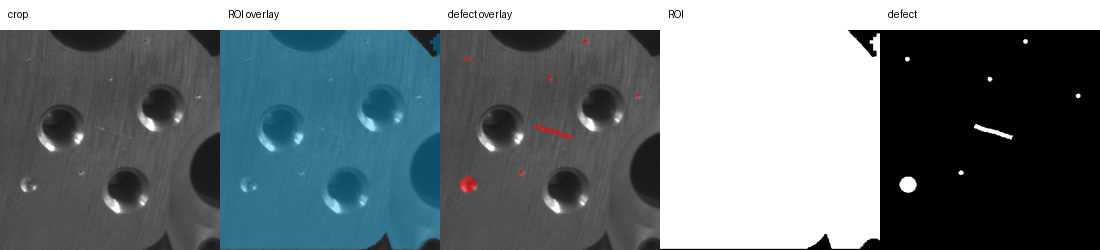

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_hss-iad_Casting_class1_preview_01.png


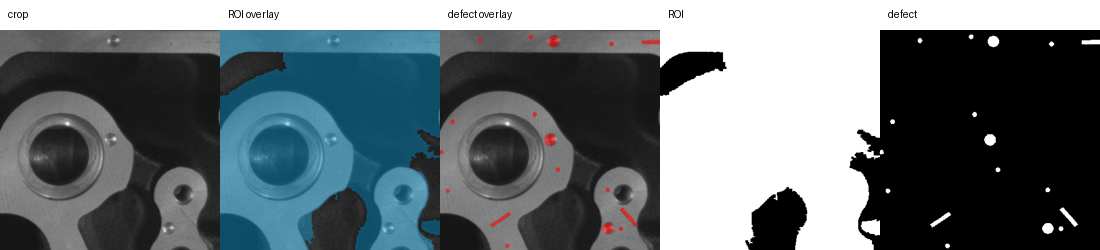

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_hss-iad_Casting_class1_preview_02.png


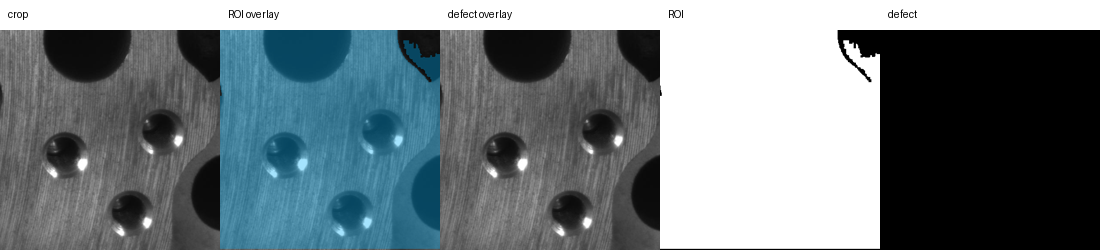

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_hss-iad_STEEL_preview_00.png


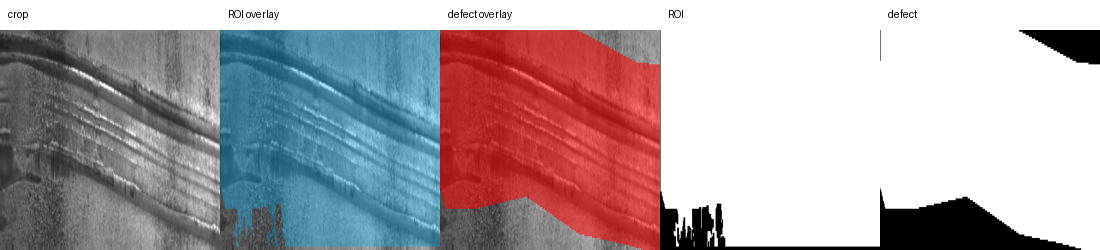

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_hss-iad_STEEL_preview_01.png


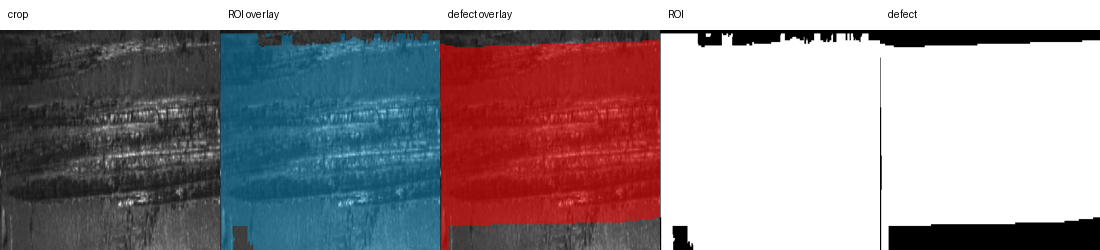

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_hss-iad_STEEL_preview_02.png


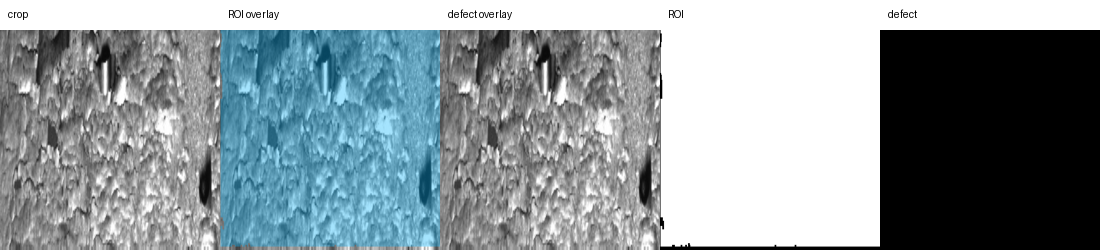

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_mvtec_cable_preview_00.png


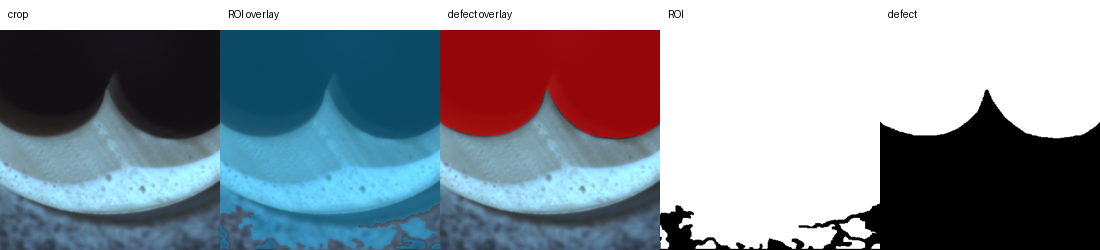

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_mvtec_cable_preview_01.png


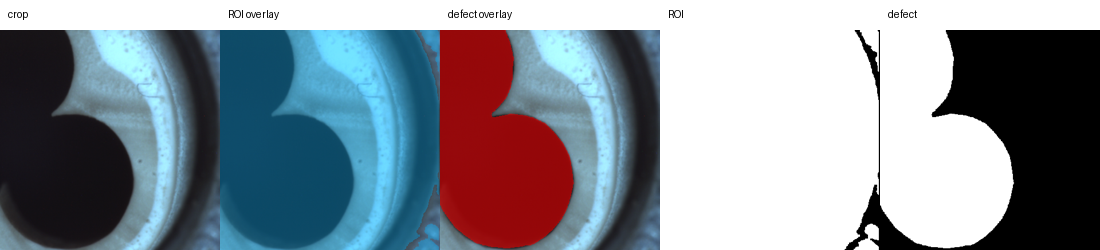

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_base_filtered_mvtec_cable_preview_02.png


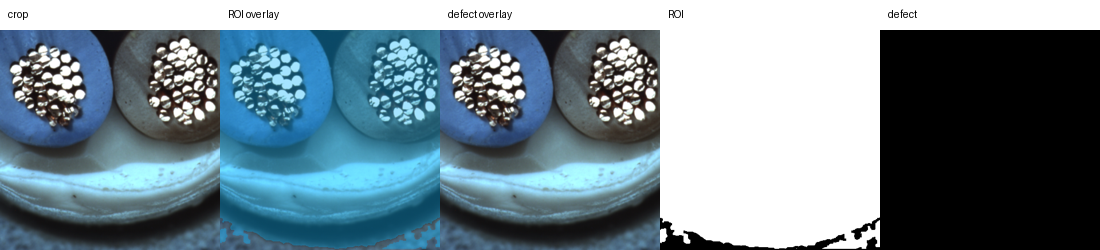

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_defect_centered_hss-iad_Casting_class1_preview_00.png


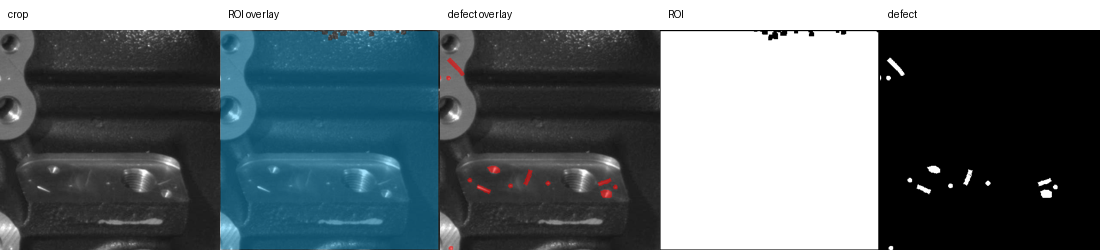

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_defect_centered_hss-iad_Casting_class1_preview_01.png


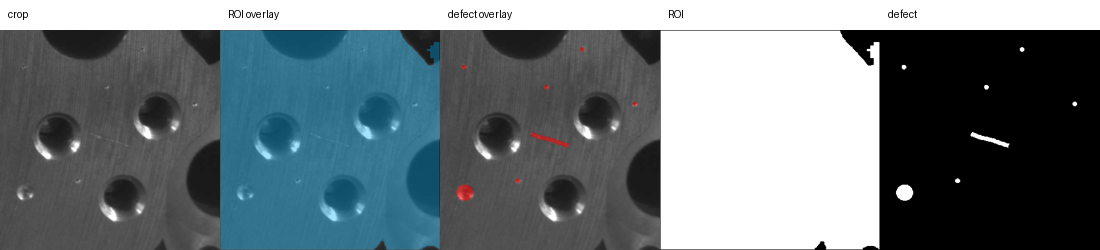

/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/previews/v6_defect_centered_hss-iad_Casting_class1_preview_02.png


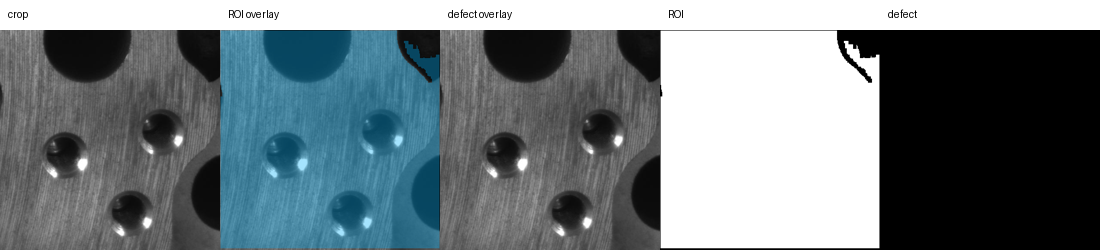

In [10]:
########################
#  Quality previews    #
########################

PREVIEW_DIR = RUN_RESULTS_DIR / "previews"
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

def make_overlay(img, mask_arr, color=(255, 0, 0), alpha=0.45):
    img = img.convert("RGB")
    arr = np.array(img).astype(np.float32)
    mask = np.asarray(mask_arr).astype(bool)

    if mask.shape[:2] != arr.shape[:2]:
        mask_img = array_to_mask(mask)
        mask_img = mask_img.resize(img.size, Image.Resampling.NEAREST)
        mask = np.array(mask_img) > MASK_THRESHOLD

    color_arr = np.array(color, dtype=np.float32)
    arr[mask] = (1 - alpha) * arr[mask] + alpha * color_arr

    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def save_preview(row, out_path):
    img = load_rgb(row["v6_crop_image_path"])
    roi_arr = load_binary_mask(row["v6_crop_roi_path"], target_size=img.size)
    defect_arr = load_binary_mask(row["v6_crop_defect_mask_path"], target_size=img.size)

    roi_overlay = make_overlay(img, roi_arr, color=(0, 180, 255), alpha=0.35)
    defect_overlay = make_overlay(img, defect_arr, color=(255, 0, 0), alpha=0.55)

    panels = [
        img.resize((220, 220)),
        roi_overlay.resize((220, 220)),
        defect_overlay.resize((220, 220)),
        array_to_mask(roi_arr).convert("RGB").resize((220, 220)),
        array_to_mask(defect_arr).convert("RGB").resize((220, 220)),
    ]

    titles = [
        "crop",
        "ROI overlay",
        "defect overlay",
        "ROI",
        "defect",
    ]

    canvas = Image.new("RGB", (220 * len(panels), 250), "white")
    draw = ImageDraw.Draw(canvas)

    for i, panel in enumerate(panels):
        x = 220 * i
        canvas.paste(panel, (x, 30))
        draw.text((x + 8, 8), titles[i], fill=(0, 0, 0))

    canvas.save(out_path)
    return out_path


preview_rows = []

for (variant_id, dataset, category), group in v6_crop_metadata_df.groupby(["variant_id", "dataset", "category"]):
    anomaly_top = (
        group[group["image_true_label"].astype(int) == 1]
        .sort_values("quality_score_v6", ascending=False)
        .head(2)
    )

    normal_top = (
        group[group["image_true_label"].astype(int) == 0]
        .sort_values("quality_score_v6", ascending=False)
        .head(1)
    )

    samples = pd.concat([anomaly_top, normal_top], ignore_index=True)

    for idx, row in samples.iterrows():
        safe_variant = str(variant_id).replace("/", "_")
        safe_dataset = str(dataset).replace("/", "_")
        safe_category = str(category).replace("/", "_")
        out_path = PREVIEW_DIR / f"{safe_variant}_{safe_dataset}_{safe_category}_preview_{idx:02d}.png"
        save_preview(row, out_path)
        preview_rows.append({
            "variant_id": variant_id,
            "dataset": dataset,
            "category": category,
            "preview_path": str(out_path),
        })

preview_df = pd.DataFrame(preview_rows)

display(preview_df)

for _, row in preview_df.head(12).iterrows():
    print(row["preview_path"])
    display(Image.open(row["preview_path"]))


## 10. Règles pour Dinomaly V14

In [11]:
####################################
#  Rules for future Dinomaly V14    #
####################################

rules_rows = []

for cfg in VARIANT_CONFIGS:
    variant_id = cfg["variant_id"]

    for dataset, category in TARGET_PAIRS:
        summary = variant_summary_df[
            (variant_summary_df["variant_id"] == variant_id)
            & (variant_summary_df["dataset"] == dataset)
            & (variant_summary_df["category"] == category)
        ]

        if len(summary) == 0:
            continue

        s = summary.iloc[0]

        rules_rows.append({
            "dataset": dataset,
            "category": category,
            "preprocessing_version": "dual_context_roi_v6_3cat_crop_quality",
            "variant_id": variant_id,
            "variant_description": cfg["description"],
            "roi_variant": cfg["roi_variant"],
            "selection_mode": cfg["selection_mode"],
            "local_size": LOCAL_SIZE,
            "use_roi": True,
            "use_local_crops": True,
            "ignore_background_for_pixel_metrics": True,
            "rows": s["rows"],
            "images": s["images"],
            "normal_crops": s["normal_crops"],
            "anomaly_crops": s["anomaly_crops"],
            "mean_roi_coverage": s["mean_roi_coverage"],
            "mean_quality_score": s["mean_quality_score"],
            "mean_defect_ratio_in_roi_anomaly": s["mean_defect_ratio_in_roi_anomaly"],
            "mean_defect_coverage_by_roi_anomaly": s["mean_defect_coverage_by_roi_anomaly"],
        })

rules_v6_df = pd.DataFrame(rules_rows)

display(rules_v6_df)


,dataset,category,preprocessing_version,variant_id,variant_description,roi_variant,selection_mode,local_size,use_roi,use_local_crops,ignore_background_for_pixel_metrics,rows,images,normal_crops,anomaly_crops,mean_roi_coverage,mean_quality_score,mean_defect_ratio_in_roi_anomaly,mean_defect_coverage_by_roi_anomaly
0,hss-iad,Casting_class1,dual_context_roi_v6_3cat_crop_quality,v6_base_filtered,V5 crops avec filtrage qualité léger,roi,base_filtered,384,True,True,True,1371,356,1266,105,0.620469,0.858787,0.014911,0.997514
1,hss-iad,STEEL,dual_context_roi_v6_3cat_crop_quality,v6_base_filtered,V5 crops avec filtrage qualité léger,roi,base_filtered,384,True,True,True,1850,672,1450,400,0.882517,1.492934,0.256988,0.993969
2,mvtec,cable,dual_context_roi_v6_3cat_crop_quality,v6_base_filtered,V5 crops avec filtrage qualité léger,roi,base_filtered,384,True,True,True,1726,374,1351,375,0.903514,1.386583,0.128324,1.000000
3,hss-iad,Casting_class1,dual_context_roi_v6_3cat_crop_quality,v6_roi_erode1_filtered,ROI érodée 1 pixel plus filtrage qualité,roi_erode_1,base_filtered,384,True,True,True,1374,371,1267,107,0.646603,0.890204,0.015127,0.988074
4,hss-iad,STEEL,dual_context_roi_v6_3cat_crop_quality,v6_roi_erode1_filtered,ROI érodée 1 pixel plus filtrage qualité,roi_erode_1,base_filtered,384,True,True,True,1850,620,1450,400,0.900734,1.537048,0.293485,0.974061
5,mvtec,cable,dual_context_roi_v6_3cat_crop_quality,v6_roi_erode1_filtered,ROI érodée 1 pixel plus filtrage qualité,roi_erode_1,base_filtered,384,True,True,True,1755,374,1369,386,0.885164,1.371864,0.129587,0.988253
6,hss-iad,Casting_class1,dual_context_roi_v6_3cat_crop_quality,v6_roi_erode2_filtered,ROI érodée 2 pixels plus filtrage qualité,roi_erode_2,base_filtered,384,True,True,True,1378,267,1267,111,0.829577,1.103065,0.015165,0.975355
7,hss-iad,STEEL,dual_context_roi_v6_3cat_crop_quality,v6_roi_erode2_filtered,ROI érodée 2 pixels plus filtrage qualité,roi_erode_2,base_filtered,384,True,True,True,1850,587,1450,400,0.900532,1.543130,0.300649,0.961007
8,mvtec,cable,dual_context_roi_v6_3cat_crop_quality,v6_roi_erode2_filtered,ROI érodée 2 pixels plus filtrage qualité,roi_erode_2,base_filtered,384,True,True,True,1850,365,1450,400,0.902517,1.427438,0.172500,0.988692
9,hss-iad,Casting_class1,dual_context_roi_v6_3cat_crop_quality,v6_top_quality_balanced,"Crops les plus propres, équilibrés par image",roi_erode_1,top_quality_balanced,384,True,True,True,1338,419,1246,92,0.595370,0.826381,0.014761,0.989474


## 11. Sauvegarde

In [12]:
##################
#  Save outputs  #
##################

quality_path = RUN_RESULTS_DIR / "dual_context_roi_v6_3cat_quality_all_roi_variants.csv"
crop_metadata_path = RUN_RESULTS_DIR / "dual_context_roi_v6_3cat_crop_metadata.csv"
variant_summary_path = RUN_RESULTS_DIR / "dual_context_roi_v6_3cat_variant_summary.csv"
rules_path = RUN_RESULTS_DIR / "preprocessing_rules_v6_dinomaly_3cat.csv"
previews_path = RUN_RESULTS_DIR / "dual_context_roi_v6_3cat_previews.csv"
errors_path = RUN_RESULTS_DIR / "dual_context_roi_v6_3cat_errors.csv"

quality_df.to_csv(quality_path, index=False)
v6_crop_metadata_df.to_csv(crop_metadata_path, index=False)
variant_summary_df.to_csv(variant_summary_path, index=False)
rules_v6_df.to_csv(rules_path, index=False)
preview_df.to_csv(previews_path, index=False)
v6_errors_df.to_csv(errors_path, index=False)

print("Saved outputs:")
for path in [
    quality_path,
    crop_metadata_path,
    variant_summary_path,
    rules_path,
    previews_path,
    errors_path,
]:
    print(path)


Saved outputs:
/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/dual_context_roi_v6_3cat_quality_all_roi_variants.csv
/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/dual_context_roi_v6_3cat_crop_metadata.csv
/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/dual_context_roi_v6_3cat_variant_summary.csv
/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/preprocessing_rules_v6_dinomaly_3cat.csv
/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3cat_crop_quality/dual_context_roi_v6_3cat_previews.csv
/home/nat/Documents/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_dual_context_roi_v6_3c

## 12. Conclusion attendue

À regarder avant de lancer Dinomaly V14 :

```text
1. Les previews sont propres pour les 3 catégories.
2. Les variantes ne suppriment pas les défauts.
3. Les ROI érodées gardent une couverture défaut suffisante.
4. La variante top quality balanced réduit les crops inutiles.
5. La variante defect centered garde mieux les défauts visibles.
6. La stratégie peut être différente selon cable, Casting_class1 et STEEL.
```

La prochaine étape sera :

```text
06_dinomaly_V14_3cat_from_preprocessing_v6.ipynb
```

Le futur notebook V14 devra tester les variantes `variant_id` générées ici et comparer :

```text
image AUROC
pixel AUROC
AUPIMO
```
